# Agisoft Calibration Quality Analysis
Analyse which field × date combinations have the worst reconstruction quality across four metrics:
- **% Aligned cameras**
- **Mean reprojection error (px)**
- **Mean 3D marker error (m)**
- **Avg distance error vs ruler (m)**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from pathlib import Path

SUMMARY_CSV = Path("/home/jgajardo/public-mnt/Evaluation/Projects/KP0034_jgajardo/data/my_data/wheat_smartphone_images/strickhof_fields/2025/demoanlage/processed/v0/marker_errors_summary.csv")

# Thresholds for flagging bad sessions (adjust as needed)
THRESH_ALIGNED_PCT  = 80   # % aligned below this is bad
THRESH_REPROJ_PX    = 8.0  # mean reproj error above this is bad
THRESH_3D_M         = 0.03 # mean 3D error above this is bad
THRESH_DIST_M       = 0.01 # avg distance error above this is bad

In [21]:
df = pd.read_csv(SUMMARY_CSV)
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')
df['% Aligned'] = (df['Aligned Cameras'] / df['Cameras'] * 100).round(1)
df = df.sort_values(['Date', 'Field']).reset_index(drop=True)

df = df.rename(columns={
    'Reproj Error (px) mean': 'Reproj (px)',
    '3D Error (m) mean':      '3D Error (m)',
    'Avg Distance Error (m)': 'Dist Error (m)',
})

METRICS = {
    '% Aligned':      {'higher_is_better': True,  'fmt': '.1f',  'unit': '%',  'log_scale': False},
    'Reproj (px)':    {'higher_is_better': False, 'fmt': '.2f',  'unit': 'px', 'log_scale': True},
    '3D Error (m)':   {'higher_is_better': False, 'fmt': '.4f',  'unit': 'm',  'log_scale': True},
    'Dist Error (m)': {'higher_is_better': False, 'fmt': '.4f',  'unit': 'm',  'log_scale': True},
}

print(f"Sessions: {len(df)}  |  Dates: {df['Date'].nunique()}  |  Fields: {df['Field'].nunique()}")
df[['Date','Field','Cameras','Aligned Cameras','% Aligned','Reproj (px)','3D Error (m)','Dist Error (m)']].head(8)

Sessions: 148  |  Dates: 37  |  Fields: 4


,Date,Field,Cameras,Aligned Cameras,% Aligned,Reproj (px),3D Error (m),Dist Error (m)
0,2025-03-21,field_A,81,81,100.0,4.856800,0.016633,0.0151
1,2025-03-21,field_B,72,72,100.0,5.642600,0.014950,0.0031
2,2025-03-21,field_C,85,85,100.0,5.825367,0.007500,0.0075
3,2025-03-21,field_D,87,87,100.0,6.091167,0.007283,0.0048
4,2025-03-25,field_A,79,79,100.0,9.413767,0.015550,0.0152
5,2025-03-25,field_B,94,94,100.0,10.469033,0.013867,0.0032
6,2025-03-25,field_C,72,72,100.0,9.332700,0.008167,0.0075
7,2025-03-25,field_D,72,72,100.0,9.680267,0.010483,0.0068


## Overall distribution

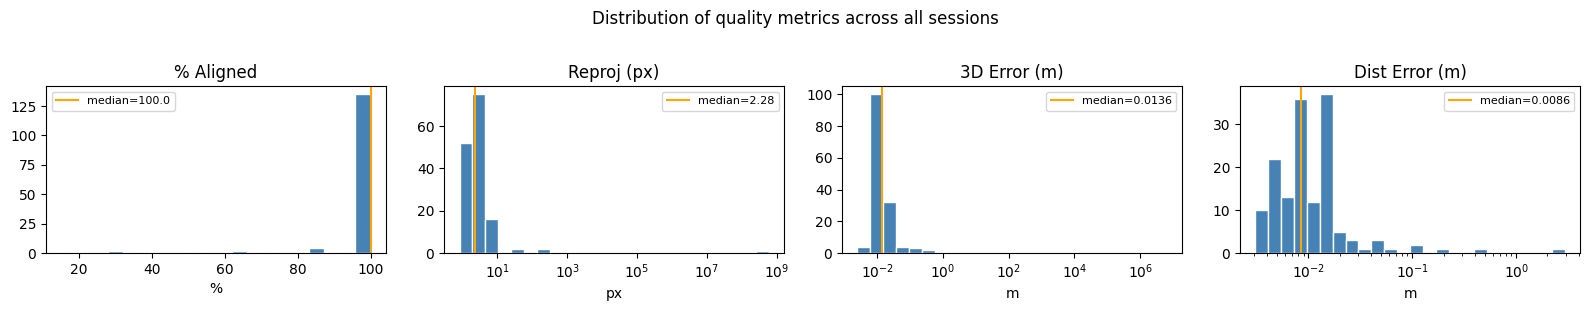

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, (col, meta) in zip(axes, METRICS.items()):
    data = df[col].dropna()
    if meta['log_scale']:
        data = data[data > 0]
        bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 25)
        ax.hist(data, bins=bins, edgecolor='white', color='steelblue')
        ax.set_xscale('log')
    else:
        ax.hist(data, bins=20, edgecolor='white', color='steelblue')
    ax.axvline(data.median(), color='orange', lw=1.5, label=f'median={data.median():{meta["fmt"]}}')
    ax.set_title(col)
    ax.set_xlabel(meta['unit'])
    ax.legend(fontsize=8)
fig.suptitle('Distribution of quality metrics across all sessions', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Heatmaps: date × field

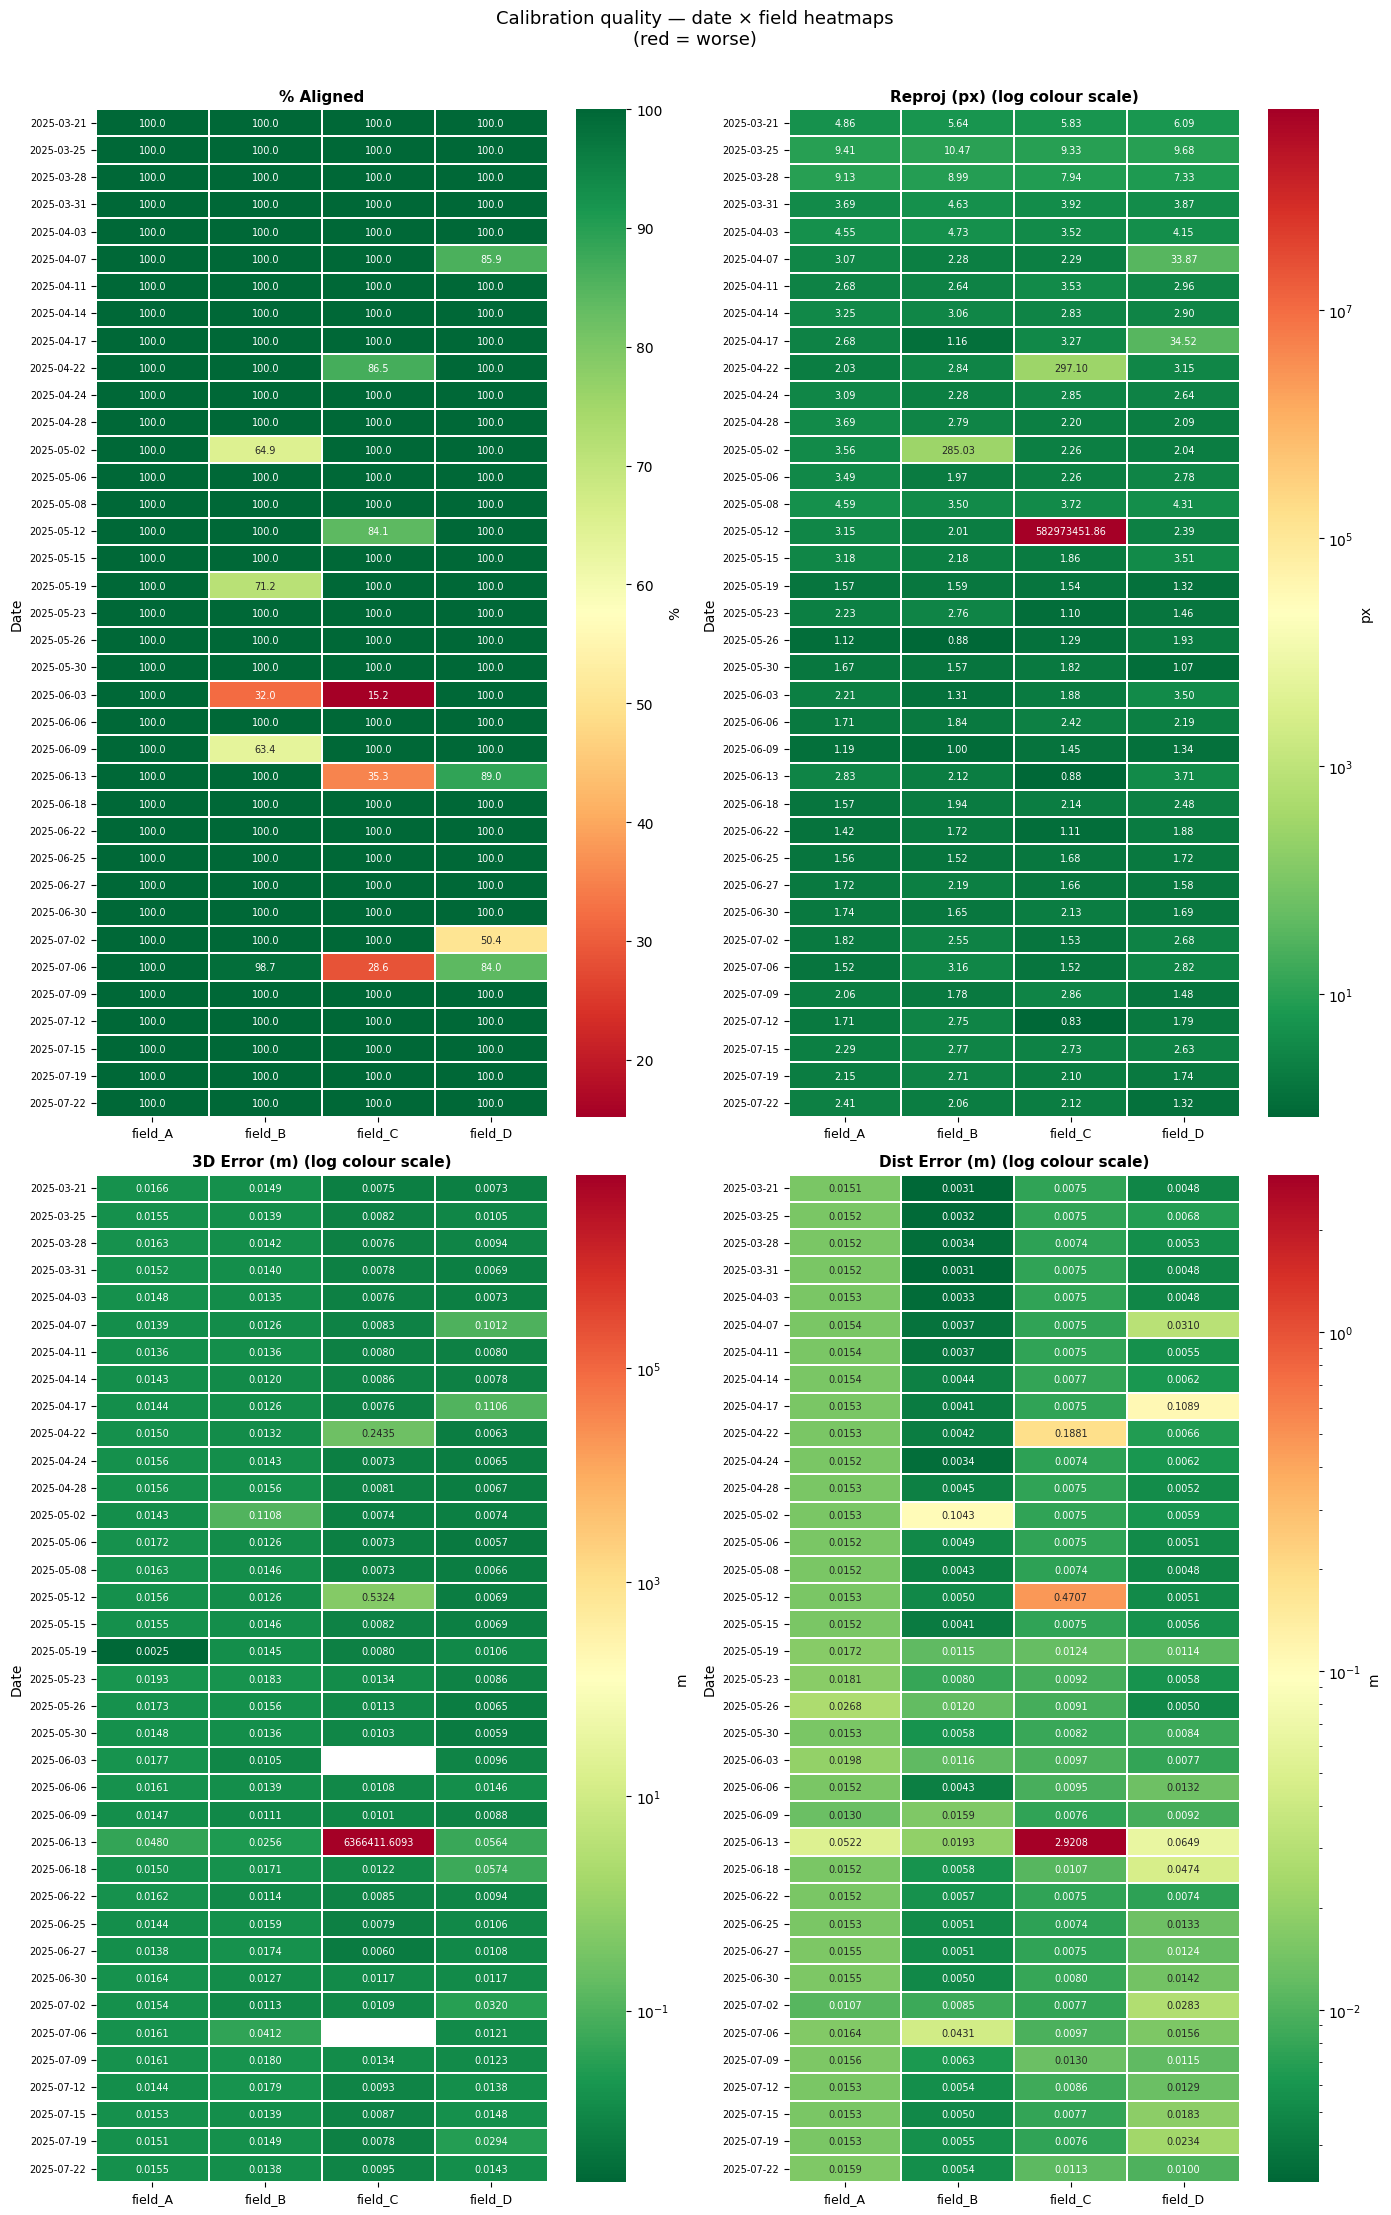

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 22))

for ax, (col, meta) in zip(axes.flat, METRICS.items()):
    pivot = df.pivot_table(index='Date', columns='Field', values=col, aggfunc='mean')
    pivot.index = pivot.index.strftime('%Y-%m-%d')
    cmap = 'RdYlGn' if meta['higher_is_better'] else 'RdYlGn_r'

    # Build annotation text from raw values so they stay human-readable on log scale
    annot = pivot.applymap(lambda x: f'{x:{meta["fmt"]}}' if pd.notna(x) else '')

    if meta['log_scale']:
        vals = pivot.values[pivot.values > 0]
        norm = LogNorm(vmin=vals.min(), vmax=vals.max()) if len(vals) else None
    else:
        norm = None

    sns.heatmap(
        pivot, ax=ax, cmap=cmap, norm=norm,
        annot=annot, fmt='', linewidths=0.3,
        cbar_kws={'label': meta['unit']},
        annot_kws={'size': 7},
    )
    scale_label = ' (log colour scale)' if meta['log_scale'] else ''
    ax.set_title(col + scale_label, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Date')
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=7)

fig.suptitle('Calibration quality — date × field heatmaps\n(red = worse)', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

## Time-series per field

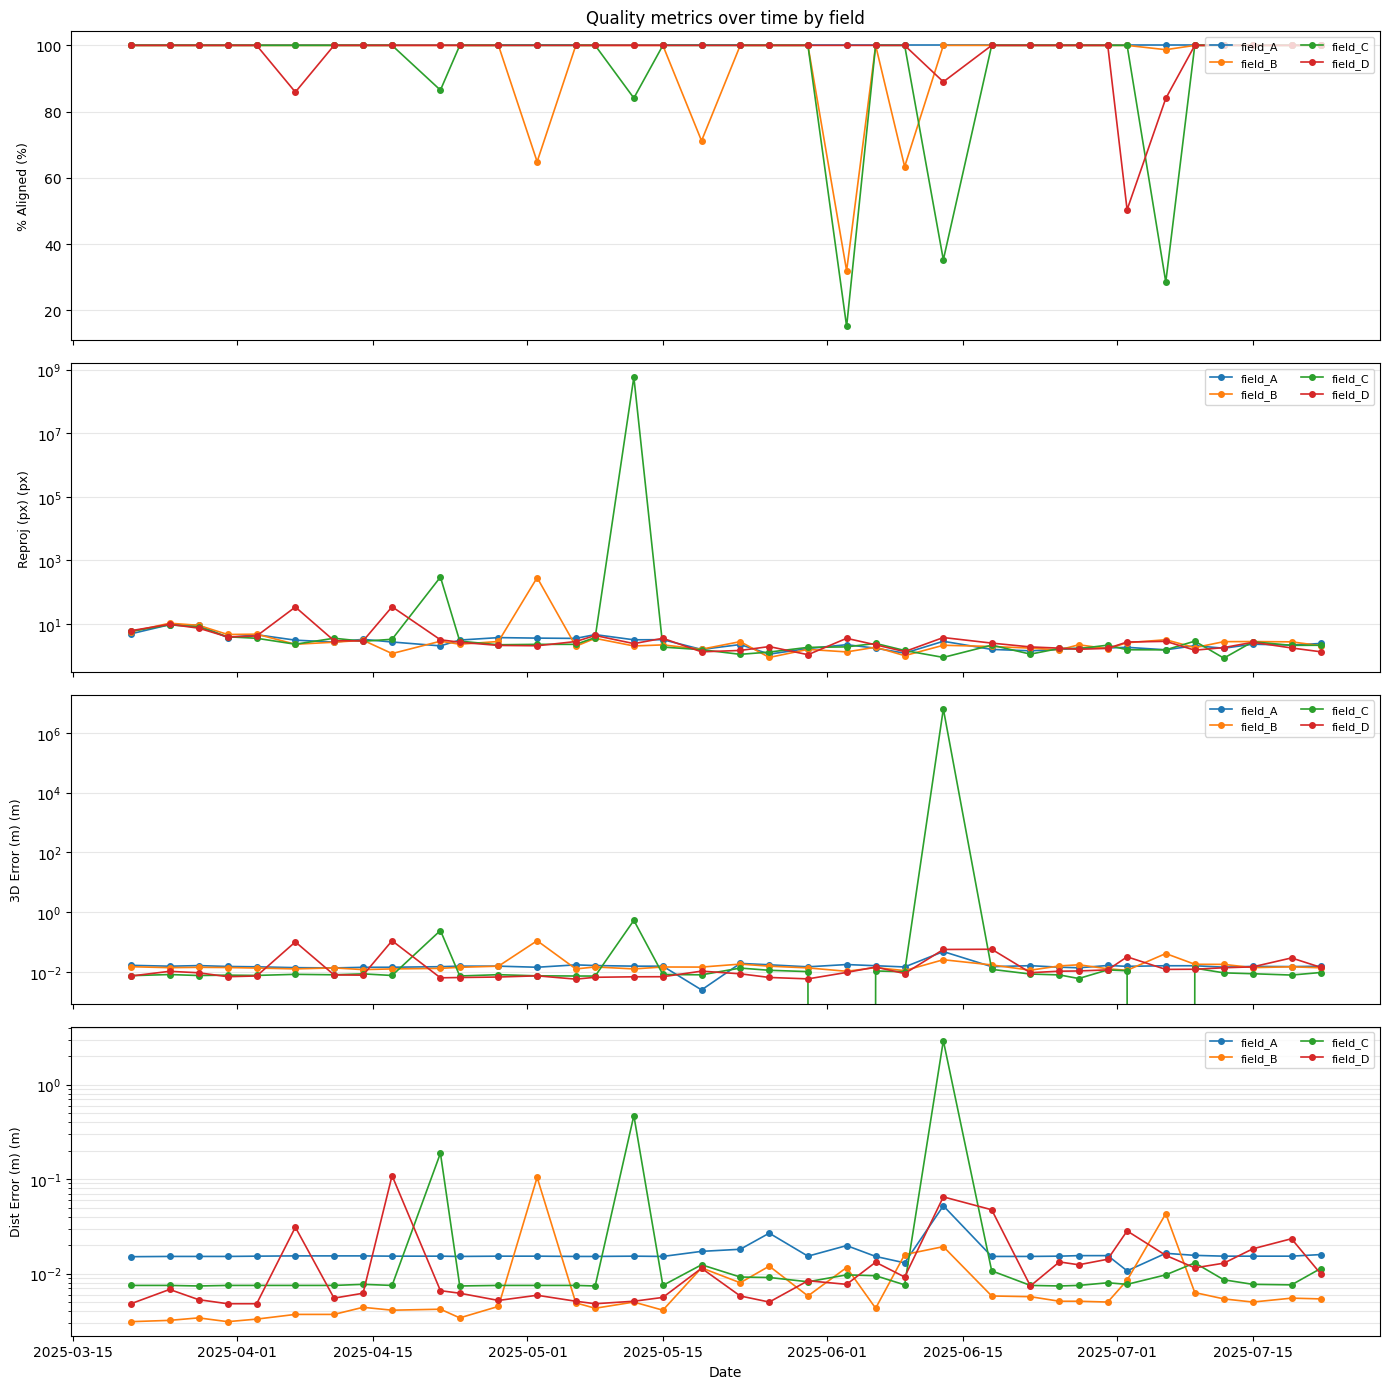

In [24]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
palette = sns.color_palette('tab10', n_colors=df['Field'].nunique())

for ax, (col, meta) in zip(axes, METRICS.items()):
    for color, (field, grp) in zip(palette, df.groupby('Field')):
        ax.plot(grp['Date'], grp[col], marker='o', markersize=4, lw=1.2, label=field, color=color)
    if meta['log_scale']:
        ax.set_yscale('log')
    ax.set_ylabel(f"{col} ({meta['unit']})", fontsize=9)
    ax.grid(axis='y', alpha=0.3, which='both')
    ax.legend(loc='upper right', fontsize=8, ncol=2)

axes[0].set_title('Quality metrics over time by field', fontsize=12)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## Worst sessions per metric
Bottom 10 sessions for each metric.

In [25]:
display_cols = ['Date', 'Field', '% Aligned', 'Reproj (px)', '3D Error (m)', 'Dist Error (m)']
N = 10

for col, meta in METRICS.items():
    ascending = meta['higher_is_better']  # True → sort ascending (lowest % aligned first)
    worst = df[display_cols].sort_values(col, ascending=ascending).head(N).copy()
    worst['Date'] = worst['Date'].dt.strftime('%Y-%m-%d')
    print(f"\n{'─'*60}")
    print(f"  Worst {N} sessions by {col}")
    print(f"{'─'*60}")
    print(worst.to_string(index=False))


────────────────────────────────────────────────────────────
  Worst 10 sessions by % Aligned
────────────────────────────────────────────────────────────
      Date   Field  % Aligned  Reproj (px)  3D Error (m)  Dist Error (m)
2025-06-03 field_C       15.2 1.884600e+00  0.000000e+00          0.0097
2025-07-06 field_C       28.6 1.521400e+00  0.000000e+00          0.0097
2025-06-03 field_B       32.0 1.307575e+00  1.051667e-02          0.0116
2025-06-13 field_C       35.3 8.785000e-01  6.366412e+06          2.9208
2025-07-02 field_D       50.4 2.680675e+00  3.198000e-02          0.0283
2025-06-09 field_B       63.4 9.990000e-01  1.108333e-02          0.0159
2025-05-02 field_B       64.9 2.850335e+02  1.107667e-01          0.1043
2025-05-19 field_B       71.2 1.589340e+00  1.453333e-02          0.0115
2025-07-06 field_D       84.0 2.815180e+00  1.213333e-02          0.0156
2025-05-12 field_C       84.1 5.829735e+08  5.324167e-01          0.4707

────────────────────────────────────────

## Composite quality score
Each metric is ranked 1–N (1 = best). The composite score is the mean rank — lower is better overall.

In [26]:
scored = df[['Date', 'Field'] + list(METRICS)].copy()

for col, meta in METRICS.items():
    # rank(ascending=True) → smallest value gets rank 1
    # For metrics where lower is better (e.g. reproj error), rank 1 = best
    # For metrics where higher is better (e.g. % aligned), we flip so rank 1 = best
    ascending = not meta['higher_is_better']
    scored[f'{col}_rank'] = scored[col].rank(ascending=ascending, method='min')

rank_cols = [f'{c}_rank' for c in METRICS]
scored['Composite Score'] = scored[rank_cols].mean(axis=1).round(1)
# Lower composite score = better overall (closer to rank 1 on all metrics)
# Higher composite score = worse overall
scored = scored.sort_values('Composite Score', ascending=False)  # worst first
scored['Date'] = scored['Date'].dt.strftime('%Y-%m-%d')

print("Top 15 worst sessions  |  Composite score: LOWER = better, HIGHER = worse")
print("─" * 80)
display(scored[['Date', 'Field', '% Aligned', 'Reproj (px)', '3D Error (m)', 'Dist Error (m)', 'Composite Score']].head(15))

Top 15 worst sessions  |  Composite score: LOWER = better, HIGHER = worse
────────────────────────────────────────────────────────────────────────────────


,Date,Field,% Aligned,Reproj (px),3D Error (m),Dist Error (m),Composite Score
62,2025-05-12,field_C,84.1,5.829735e+08,5.324167e-01,0.4707,145.2
49,2025-05-02,field_B,64.9,2.850335e+02,1.107667e-01,0.1043,144.2
38,2025-04-22,field_C,86.5,2.970994e+02,2.434833e-01,0.1881,144.0
23,2025-04-07,field_D,85.9,3.387063e+01,1.012500e-01,0.0310,141.0
99,2025-06-13,field_D,89.0,3.709050e+00,5.638333e-02,0.0649,135.5
125,2025-07-06,field_B,98.7,3.164450e+00,4.123333e-02,0.0431,130.8
123,2025-07-02,field_D,50.4,2.680675e+00,3.198000e-02,0.0283,126.8
98,2025-06-13,field_C,35.3,8.785000e-01,6.366412e+06,2.9208,111.0
35,2025-04-17,field_D,100.0,3.452135e+01,1.106167e-01,0.1089,108.8
127,2025-07-06,field_D,84.0,2.815180e+00,1.213333e-02,0.0156,106.2


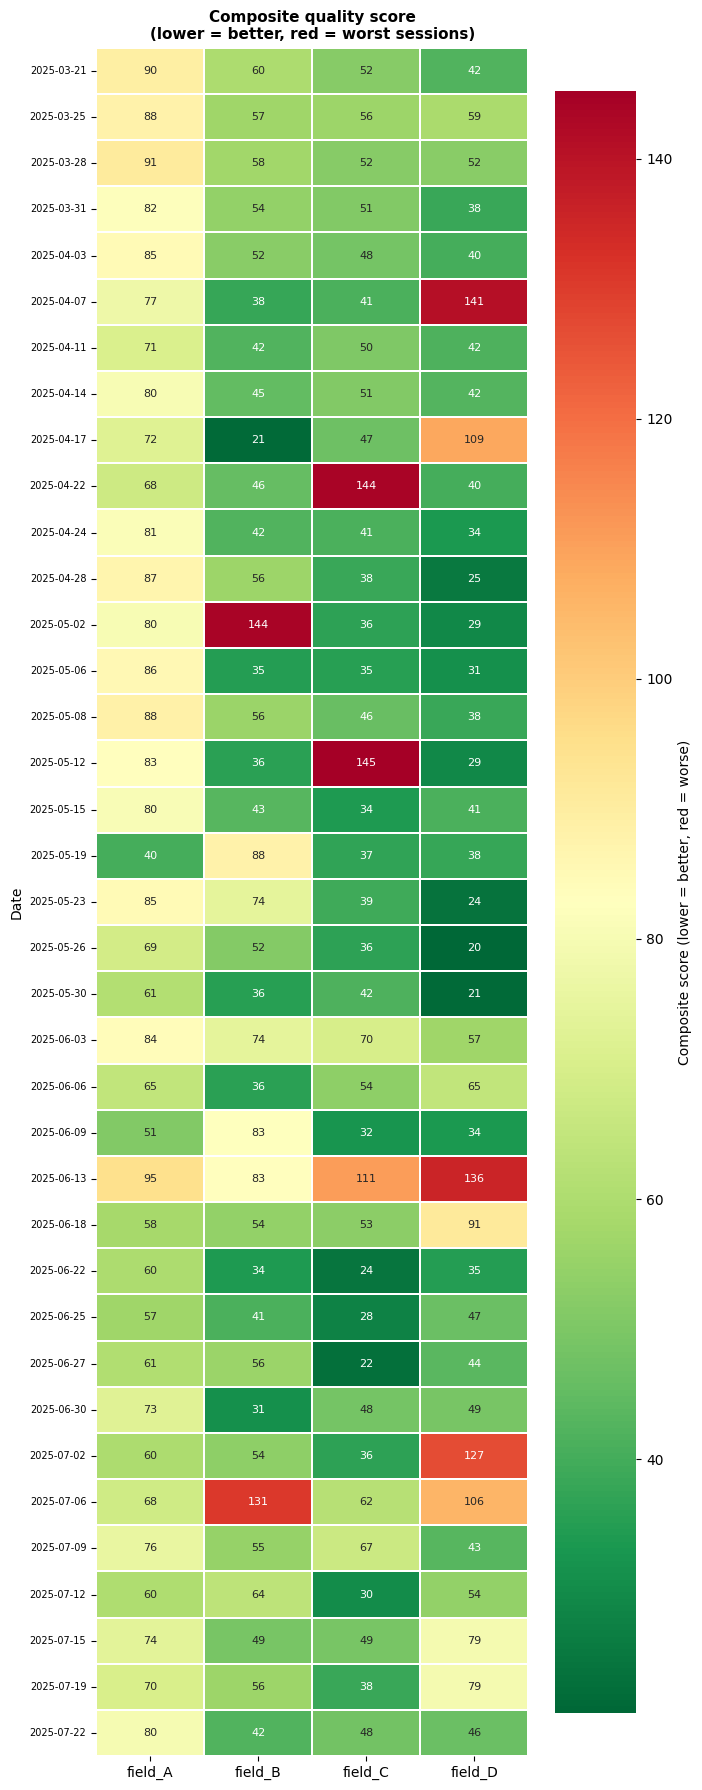

In [27]:
scored_orig = df[['Date', 'Field'] + list(METRICS)].copy()
for col, meta in METRICS.items():
    ascending = not meta['higher_is_better']
    scored_orig[f'{col}_rank'] = scored_orig[col].rank(ascending=ascending, method='min')
scored_orig['Composite Score'] = scored_orig[[f'{c}_rank' for c in METRICS]].mean(axis=1).round(1)

pivot_score = scored_orig.pivot_table(index='Date', columns='Field', values='Composite Score')
pivot_score.index = pivot_score.index.strftime('%Y-%m-%d')

fig, ax = plt.subplots(figsize=(7, 18))
sns.heatmap(
    pivot_score, ax=ax,
    cmap='RdYlGn_r',   # red = high score = WORSE
    annot=True, fmt='.0f', linewidths=0.3,
    cbar_kws={'label': 'Composite score (lower = better, red = worse)'},
    annot_kws={'size': 8},
)
ax.set_title('Composite quality score\n(lower = better, red = worst sessions)', fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

## Per-field summary statistics

In [28]:
summary = df.groupby('Field')[list(METRICS)].agg(['mean', 'std', 'min', 'max']).round(4)
summary.columns = [' '.join(c) for c in summary.columns]
summary

,% Aligned mean,% Aligned std,% Aligned min,% Aligned max,Reproj (px) mean,Reproj (px) std,Reproj (px) min,Reproj (px) max,3D Error (m) mean,3D Error (m) std,3D Error (m) min,3D Error (m) max,Dist Error (m) mean,Dist Error (m) std,Dist Error (m) min,Dist Error (m) max
Field,,,,,,,,,,,,,,,,
field_A,100.0000,0.0000,100.0,100.0,2.880700e+00,1.828600e+00,1.1156,9.413800e+00,0.0161,5.900000e-03,0.0025,4.800000e-02,0.0167,0.0064,0.0107,0.0522
field_B,95.4108,14.1887,32.0,100.0,1.043470e+01,4.643910e+01,0.8756,2.850335e+02,0.0178,1.650000e-02,0.0105,1.108000e-01,0.0098,0.0175,0.0031,0.1043
field_C,93.2351,20.5595,15.2,100.0,1.575605e+07,9.584024e+07,0.8327,5.829735e+08,172065.2074,1.046632e+06,0.0000,6.366412e+06,0.1044,0.4827,0.0074,2.9208
field_D,97.5486,8.8406,50.4,100.0,4.557400e+00,7.389500e+00,1.0701,3.452140e+01,0.0182,2.440000e-02,0.0057,1.106000e-01,0.0152,0.0202,0.0048,0.1089


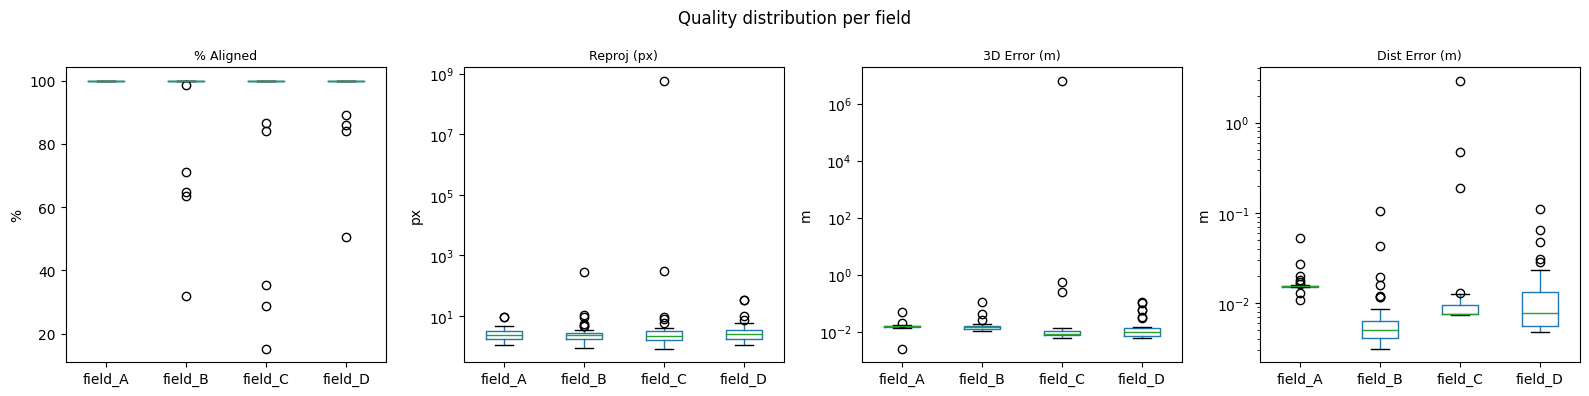

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (col, meta) in zip(axes, METRICS.items()):
    df.boxplot(column=col, by='Field', ax=ax, grid=False)
    if meta['log_scale']:
        ax.set_yscale('log')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel(meta['unit'])
plt.suptitle('Quality distribution per field')
plt.tight_layout()
plt.show()

## Flag sessions exceeding thresholds

In [30]:
flagged = df[
    (df['% Aligned']      < THRESH_ALIGNED_PCT) |
    (df['Reproj (px)']    > THRESH_REPROJ_PX)   |
    (df['3D Error (m)']   > THRESH_3D_M)        |
    (df['Dist Error (m)'] > THRESH_DIST_M)
].copy()

flagged['Low align']  = flagged['% Aligned']      < THRESH_ALIGNED_PCT
flagged['High reproj']= flagged['Reproj (px)']    > THRESH_REPROJ_PX
flagged['High 3D']    = flagged['3D Error (m)']   > THRESH_3D_M
flagged['High dist']  = flagged['Dist Error (m)'] > THRESH_DIST_M
flagged['# Flags']    = flagged[['Low align','High reproj','High 3D','High dist']].sum(axis=1)

flagged['Date'] = flagged['Date'].dt.strftime('%Y-%m-%d')

show_cols = ['Date', 'Field', '% Aligned', 'Reproj (px)', '3D Error (m)', 'Dist Error (m)',
             'Low align', 'High reproj', 'High 3D', 'High dist', '# Flags']

print(f"{len(flagged)} sessions exceed at least one threshold  "
      f"(thresholds: aligned<{THRESH_ALIGNED_PCT}%, reproj>{THRESH_REPROJ_PX}px, "
      f"3D>{THRESH_3D_M}m, dist>{THRESH_DIST_M}m)")
display(flagged[show_cols].sort_values('# Flags', ascending=False).reset_index(drop=True))

72 sessions exceed at least one threshold  (thresholds: aligned<80%, reproj>8.0px, 3D>0.03m, dist>0.01m)


,Date,Field,% Aligned,Reproj (px),3D Error (m),Dist Error (m),Low align,High reproj,High 3D,High dist,# Flags
0,2025-05-02,field_B,64.9,2.850335e+02,1.107667e-01,0.1043,True,True,True,True,4
1,2025-04-17,field_D,100.0,3.452135e+01,1.106167e-01,0.1089,False,True,True,True,3
2,2025-06-13,field_C,35.3,8.785000e-01,6.366412e+06,2.9208,True,False,True,True,3
3,2025-05-12,field_C,84.1,5.829735e+08,5.324167e-01,0.4707,False,True,True,True,3
4,2025-07-02,field_D,50.4,2.680675e+00,3.198000e-02,0.0283,True,False,True,True,3
...,...,...,...,...,...,...,...,...,...,...,...
67,2025-05-26,field_B,100.0,8.755600e-01,1.558000e-02,0.0120,False,False,False,True,1
68,2025-05-30,field_A,100.0,1.673850e+00,1.481667e-02,0.0153,False,False,False,True,1
69,2025-06-03,field_A,100.0,2.208580e+00,1.766000e-02,0.0198,False,False,False,True,1
70,2025-06-06,field_A,100.0,1.714867e+00,1.611667e-02,0.0152,False,False,False,True,1
